# Customer & Marketing Analytics Team Assignment #2
> What Do Brands Actually Say - and Does It Work?\
> Analysing Sentiment, Topics and Emojis in Brand Social \Media Posts

> Group 10: Alice Williams, Lorenzo Zaniboni, Henry Soper, Alec Vitale, Anastasija Smiljkovska



In [ ]:
# import libraries
import io
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import emoji
import statsmodels.api as sm
import statsmodels.formula.api as smf
from google.colab import files
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline
from tqdm import tqdm
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Question 0 - Data Loading & Preparation

In [ ]:
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_excel(io.BytesIO(uploaded[file_name]), sheet_name="Social Media Posts")
print(f"Success! Loaded {len(df)} rows.")

Saving Team Assignment 2 Data 2026.xlsx to Team Assignment 2 Data 2026 (4).xlsx
Success! Loaded 600 rows.


In [ ]:
# quick general check on the data

print(df.info()) # check for missing values and data types
print(f"\nBrand balance: \n{df['Brand'].value_counts()}\n") # confirm brand balance (should be 200 each)
print(f"Missing texts: {df['Post_Text'].isnull().sum()}\n") # check for empty posts
print(f"Preview text: \n{df['Post_Text'].head(10)}\n") # preview text to ensure emojis are rendering
display(df[['Num_Likes', 'Num_Comments']].describe()) # basic distribution of engagement

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Post_ID               600 non-null    int64 
 1   Brand                 600 non-null    object
 2   Handle                600 non-null    object
 3   Post_Text             600 non-null    object
 4   Total_Followers       600 non-null    int64 
 5   Total_Posts_LastYear  600 non-null    int64 
 6   Num_Likes             600 non-null    int64 
 7   Num_Comments          600 non-null    int64 
 8   Num_Reposts           600 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 42.3+ KB
None

Brand balance: 
Brand
LumoraBeauty    200
FitPulse        200
TechNest        200
Name: count, dtype: int64

Missing texts: 0

Preview text: 
0    The order matters! Skincare layering: cleanser...
1    Current mood: applying a sheet mask and preten...
2    Your skin deserves a standing ov

,Num_Likes,Num_Comments
count,600.000000,600.000000
mean,2186.748333,142.198333
std,1703.985472,129.784819
min,173.000000,8.000000
25%,1055.000000,64.000000
50%,1759.500000,102.000000
75%,2795.750000,182.250000
max,14121.000000,1043.000000


# Question 1 - Sentiment Analysis
How Positive Are the Posts?

In [ ]:
analyzer = SentimentIntensityAnalyzer()

# get the continuous score (-1 to 1) for Q4 regression later
df['Sentiment_Score'] = df['Post_Text'].apply(lambda x: analyzer.polarity_scores(str(x))['compound'])

# categorize for visualization
df['Sentiment_Label'] = pd.cut(df['Sentiment_Score'], bins=[-1, -0.05, 0.05, 1], labels=['Negative', 'Neutral', 'Positive'])

In [ ]:
# (a) summary statistics overall
print("--- OVERALL SENTIMENT STATISTICS ---")
display(df['Sentiment_Score'].describe())

# (b) sentiment by brand (find which is most positive/negative)
brand_comparison = df.groupby('Brand')['Sentiment_Score'].agg(['mean', 'median', 'std']).sort_values(by='mean', ascending=False)
print("\n--- SENTIMENT BY BRAND (Ranked Most Positive to Least) ---")
display(brand_comparison)

# (c) label counts (positive vs neutral vs negative)
print("\n--- SENTIMENT LABEL BREAKDOWN ---")
display(df.groupby(['Brand', 'Sentiment_Label']).size().unstack())

--- OVERALL SENTIMENT STATISTICS ---


,Sentiment_Score
count,600.000000
mean,0.342841
std,0.482139
min,-0.825600
25%,0.000000
50%,0.457400
75%,0.757900
max,0.959000



--- SENTIMENT BY BRAND (Ranked Most Positive to Least) ---


,mean,median,std
Brand,,,
LumoraBeauty,0.560971,0.7184,0.429967
TechNest,0.250918,0.4215,0.457256
FitPulse,0.216633,0.2661,0.483150



--- SENTIMENT LABEL BREAKDOWN ---


Sentiment_Label,Negative,Neutral,Positive
Brand,,,
FitPulse,58,36,106
LumoraBeauty,18,13,169
TechNest,56,25,119


In [ ]:
# examine 3 most positive posts
print("--- TOP 3 MOST POSITIVE POSTS ---")
display(df.nlargest(3, 'Sentiment_Score')[['Brand', 'Post_Text', 'Sentiment_Score']])

# examine 3 most negative posts
print("\n--- TOP 3 MOST NEGATIVE POSTS ---")
display(df.nsmallest(3, 'Sentiment_Score')[['Brand', 'Post_Text', 'Sentiment_Score']])

--- TOP 3 MOST POSITIVE POSTS ---


,Brand,Post_Text,Sentiment_Score
116,LumoraBeauty,Did you know Vitamin C serums work best on cle...,0.959
117,LumoraBeauty,Did you know Vitamin C serums work best on cle...,0.959
151,LumoraBeauty,Did you know Vitamin C serums work best on cle...,0.959



--- TOP 3 MOST NEGATIVE POSTS ---


,Brand,Post_Text,Sentiment_Score
527,TechNest,That bug was 3 hours of debugging and it turne...,-0.8256
10,LumoraBeauty,That awkward moment when you realise you have ...,-0.8221
128,LumoraBeauty,Exfoliate once or twice a week to remove dull ...,-0.7966


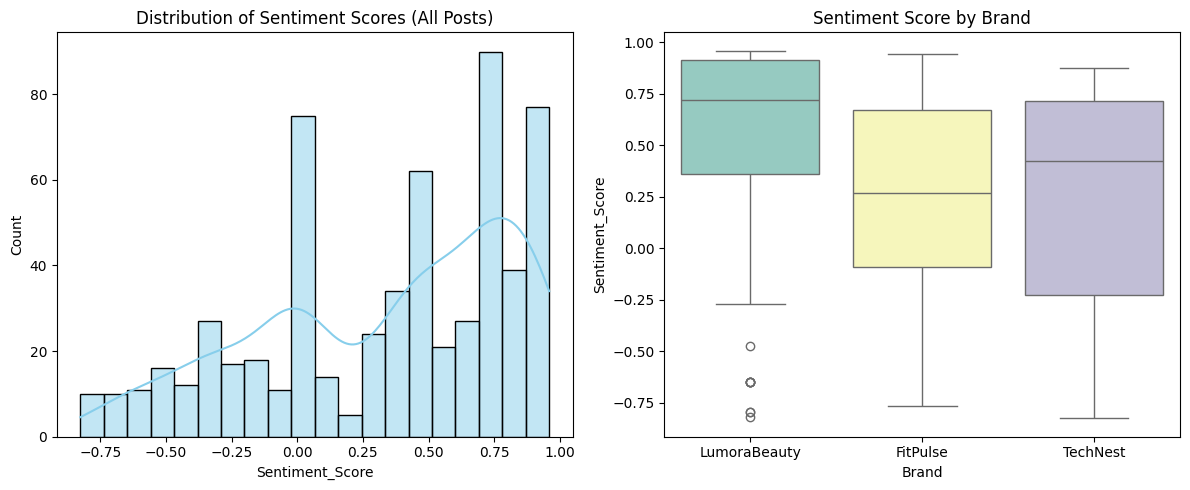

In [ ]:
plt.figure(figsize=(12, 5))

# histogram of all scores
plt.subplot(1, 2, 1)
sns.histplot(df['Sentiment_Score'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Sentiment Scores (All Posts)')

# boxplot by brand
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Brand', y='Sentiment_Score', palette='Set3')
plt.title('Sentiment Score by Brand')

plt.tight_layout()
plt.show()

# Question 2 - Topic Classification
What Are Brands Posting About?

In [ ]:
classifier = pipeline("zero-shot-classification", model="cross-encoder/nli-deberta-v3-small", device=0)
candidate_labels = ["Informative", "Entertaining", "Promotional"]

print("Classifying topics (this takes ~2 mins)...")
tqdm.pandas()
df['Topic_Class'] = df['Post_Text'].progress_apply(lambda x: classifier(str(x), candidate_labels)['labels'][0])

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: cross-encoder/nli-deberta-v3-small
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Classifying topics (this takes ~2 mins)...


100%|██████████| 600/600 [06:30<00:00,  1.54it/s]


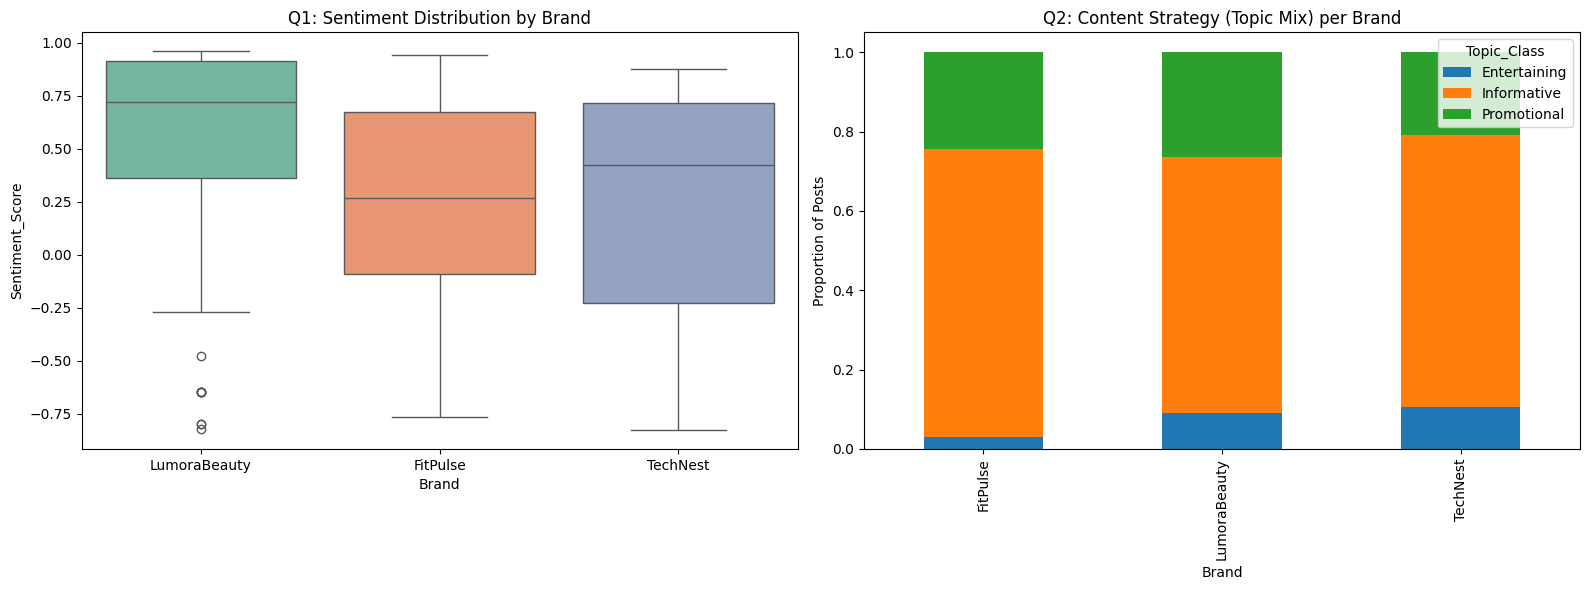

,Brand,Post_Text,Sentiment_Score,Topic_Class
0,LumoraBeauty,The order matters! Skincare layering: cleanser...,0.8313,Informative
1,LumoraBeauty,Current mood: applying a sheet mask and preten...,0.4199,Informative
2,LumoraBeauty,Your skin deserves a standing ovation today 👏✨...,0.9381,Entertaining
3,LumoraBeauty,"Our ClearCalm Blemish Serum has over 10,000 fi...",0.7579,Informative
4,LumoraBeauty,Retinol 101 🧪 Start with 0.25% twice a week at...,0.7184,Informative


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Q1 plot: sentiment by brand
sns.boxplot(data=df, x='Brand', y='Sentiment_Score', ax=ax1, palette='Set2')
ax1.set_title('Q1: Sentiment Distribution by Brand')

# Q2 plot: topic mix by brand
df.groupby('Brand')['Topic_Class'].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True, ax=ax2)
ax2.set_title('Q2: Content Strategy (Topic Mix) per Brand')
ax2.set_ylabel('Proportion of Posts')

plt.tight_layout()
plt.show()

# quick check of the results
display(df[['Brand', 'Post_Text', 'Sentiment_Score', 'Topic_Class']].head())

# Question 3 - Paralinguistic / Emoji Analysis
The Role of Emojis

In [ ]:
# function to extract emojis from text
def extract_emojis(text):
    return ''.join(c for c in str(text) if c in emoji.EMOJI_DATA)

df['Emojis'] = df['Post_Text'].apply(extract_emojis)

In [ ]:
# get top 10 emojis overall
all_emojis = "".join(df['Emojis'])
top_10_overall = Counter(all_emojis).most_common(10)

print("--- TOP 10 EMOJIS OVERALL ---")
for emo, count in top_10_overall:
    print(f"{emo} : {count}")

--- TOP 10 EMOJIS OVERALL ---
✨ : 118
👇 : 111
💪 : 96
⚡ : 71
💻 : 63
🔥 : 58
😂 : 54
💛 : 53
🌸 : 46
😅 : 43


In [ ]:
# emoji usage by brand (frequency)
print("\n--- EMOJI FREQUENCY BY BRAND ---")
df['Emoji_Count'] = df['Emojis'].apply(len)
brand_emoji_stats = df.groupby('Brand')['Emoji_Count'].mean().sort_values(ascending=False)
print(brand_emoji_stats)


--- EMOJI FREQUENCY BY BRAND ---
Brand
TechNest        2.56
LumoraBeauty    2.44
FitPulse        2.30
Name: Emoji_Count, dtype: float64


In [ ]:
# top emoji per brand
print("\n--- SIGNATURE EMOJI PER BRAND ---")
for brand in df['Brand'].unique():
    brand_text = "".join(df[df['Brand'] == brand]['Emojis'])
    top_emo = Counter(brand_text).most_common(1)
    print(f"{brand}: {top_emo[0][0]} (used {top_emo[0][1]} times)")


--- SIGNATURE EMOJI PER BRAND ---
LumoraBeauty: ✨ (used 89 times)
FitPulse: 💪 (used 93 times)
TechNest: 💻 (used 63 times)


# Question 4 - Drivers of Engagement
What Makes Posts Perform?

In [ ]:
# create dummy variables for Topic_Class, use 'Promotional' as the baseline to compare against
df_final = pd.get_dummies(df, columns=['Topic_Class'], drop_first=False)

# model for Likes
formula_likes = 'Num_Likes ~ Sentiment_Score + Emoji_Count + Topic_Class_Informative + Topic_Class_Entertaining + Total_Followers + Total_Posts_LastYear'
model_likes = smf.ols(formula=formula_likes, data=df_final).fit()

# model for Comments
formula_comments = 'Num_Comments ~ Sentiment_Score + Emoji_Count + Topic_Class_Informative + Topic_Class_Entertaining + Total_Followers + Total_Posts_LastYear'
model_comments = smf.ols(formula=formula_comments, data=df_final).fit()

print("--- REGRESSION RESULTS: LIKES ---")
print(model_likes.summary())

print("\n\n--- REGRESSION RESULTS: COMMENTS ---")
print(model_comments.summary())

--- REGRESSION RESULTS: LIKES ---
                            OLS Regression Results                            
Dep. Variable:              Num_Likes   R-squared:                       0.369
Model:                            OLS   Adj. R-squared:                  0.363
Method:                 Least Squares   F-statistic:                     57.78
Date:                Thu, 07 May 2026   Prob (F-statistic):           3.22e-56
Time:                        13:38:24   Log-Likelihood:                -5177.2
No. Observations:                 600   AIC:                         1.037e+04
Df Residuals:                     593   BIC:                         1.040e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

# Question 5 - Brand Differences
Do Engagement Drivers Differ Across Brands?

In [ ]:
# loop through each brand to compare them
brands = df['Brand'].unique()

for brand in brands:
    print(f"\n" + "="*50)
    print(f"RESULTS FOR: {brand}")
    print("="*50)

    brand_df = df_final[df_final['Brand'] == brand]

    # run Likes model for this specific brand
    model_l = smf.ols(formula=formula_likes, data=brand_df).fit()

    # run Comments model for this specific brand
    model_c = smf.ols(formula=formula_comments, data=brand_df).fit()

    print(f"--- LIKES (Predictors for {brand}) ---")
    display(model_l.summary2().tables[1][['Coef.', 'P>|t|']])

    print(f"--- COMMENTS (Predictors for {brand}) ---")
    display(model_c.summary2().tables[1][['Coef.', 'P>|t|']])


RESULTS FOR: LumoraBeauty
--- LIKES (Predictors for LumoraBeauty) ---


,Coef.,P>|t|
Intercept,7.395173e-09,5.620482e-06
Topic_Class_Informative[T.True],2.760092e+02,3.760439e-01
Topic_Class_Entertaining[T.True],-2.023512e+01,9.698808e-01
Sentiment_Score,-2.228674e+02,5.612278e-01
Emoji_Count,6.328264e+02,6.250025e-07
Total_Followers,3.586650e-03,5.619444e-06
Total_Posts_LastYear,2.351663e-06,5.620052e-06


--- COMMENTS (Predictors for LumoraBeauty) ---


,Coef.,P>|t|
Intercept,3.416838e-10,0.004280
Topic_Class_Informative[T.True],2.407890e+01,0.300951
Topic_Class_Entertaining[T.True],1.519594e+01,0.704040
Sentiment_Score,1.309933e+01,0.647190
Emoji_Count,4.001232e+01,0.000021
Total_Followers,1.657176e-04,0.004279
Total_Posts_LastYear,1.086557e-07,0.004280



RESULTS FOR: FitPulse
--- LIKES (Predictors for FitPulse) ---


...

,Coef.,P>|t|
Intercept,7.734713e-10,0.000315
Topic_Class_Informative[T.True],5.338773e-01,0.978093
Topic_Class_Entertaining[T.True],2.605752e+01,0.622417
Sentiment_Score,6.705522e+01,0.000376
Emoji_Count,2.193381e+01,0.000461
Total_Followers,2.413206e-04,0.000315
Total_Posts_LastYear,2.134763e-07,0.000315



RESULTS FOR: TechNest
--- LIKES (Predictors for TechNest) ---


,Coef.,P>|t|
Intercept,1.781384e-08,6.338508e-10
Topic_Class_Informative[T.True],-2.954438e+02,9.190916e-03
Topic_Class_Entertaining[T.True],-2.296349e+02,2.156679e-01
Sentiment_Score,3.247476e+02,3.932059e-03
Emoji_Count,1.963678e+02,1.000232e-08
Total_Followers,3.883478e-03,6.339171e-10
Total_Posts_LastYear,3.455926e-06,6.339001e-10


--- COMMENTS (Predictors for TechNest) ---


,Coef.,P>|t|
Intercept,9.017493e-10,3.796425e-04
Topic_Class_Informative[T.True],-1.297793e+01,2.058703e-01
Topic_Class_Entertaining[T.True],-2.021445e+01,2.312814e-01
Sentiment_Score,3.651919e+01,3.977541e-04
Emoji_Count,1.636841e+01,1.290148e-07
Total_Followers,1.965867e-04,3.795987e-04
Total_Posts_LastYear,1.749430e-07,3.796093e-04
